In [1]:
# ── Cell 1: Bootstrap repo root + SPEC_HASH assertion ──────────────────────
import hashlib, json, os, sys, time
from pathlib import Path

root = Path.cwd()
for _ in range(10):
    if (root / 'research' / '__init__.py').exists():
        break
    root = root.parent
else:
    raise RuntimeError('repo root not found — launch Jupyter from inside TRADING-BOT/')

os.chdir(root)
sys.path.insert(0, str(root))

from research.experiments.exp10_proxy import CONFIG
assert hashlib.sha256(
    json.dumps(CONFIG, sort_keys=True).encode()
).hexdigest()[:12] == '7a809aaca7f3', 'CONFIG no coincide con spec v1 FROZEN'

print(f'repo root : {root}')
print('SPEC_HASH : 7a809aaca7f3  OK')

repo root : C:\Users\Lenovo\Documents\TRADING-BOT
SPEC_HASH : 7a809aaca7f3  OK


In [2]:
# ── Cell 2: Imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

from research.experiments.exp10_proxy import (
    compute_bin_stats,
    detect_events,
    match_controls,
    compute_directed_returns,
    run_inference,
)

TAPE_PATH   = root / 'data' / 'raw' / 'BTCUSDT_AGGTRADES.csv'
HORIZON_MS  = CONFIG['horizon_primary_ms']   # 300_000 ms = 5 min
HORIZON_1M_MS = 60_000                        # F2 pre-registered falsifier

print(f'tape      : {TAPE_PATH}')
print(f'H_primary : {HORIZON_MS / 60_000:.0f} min')
print(f'H_F2      : {HORIZON_1M_MS / 1_000:.0f} s  (F2 falsifier)')

tape      : C:\Users\Lenovo\Documents\TRADING-BOT\data\raw\BTCUSDT_AGGTRADES.csv
H_primary : 5 min
H_F2      : 60 s  (F2 falsifier)


In [3]:
# ── Cell 3: Load tape ───────────────────────────────────────────────────────
# Only the 4 columns compute_bin_stats needs; keep float64 for price/qty.
t0 = time.time()
tape = pd.read_csv(
    TAPE_PATH,
    usecols=['timestamp_ms', 'price', 'qty', 'side'],
    dtype={'timestamp_ms': np.int64, 'price': np.float64,
           'qty': np.float64, 'side': str},
)
elapsed = time.time() - t0

tape_start = pd.to_datetime(tape['timestamp_ms'].min(), unit='ms', utc=True)
tape_end   = pd.to_datetime(tape['timestamp_ms'].max(), unit='ms', utc=True)

print(f'n_trades   : {len(tape):>12,}')
print(f'date range : {tape_start}  →  {tape_end}')
print(f'side dist  : BUY {(tape["side"]=="BUY").mean()*100:.1f}%  |  '
      f'SELL {(tape["side"]=="SELL").mean()*100:.1f}%')
print(f'loaded in  : {elapsed:.1f}s')

n_trades   :   41,544,041
date range : 2026-04-01 00:00:00.049000+00:00  →  2026-04-30 23:59:59.783000+00:00
side dist  : BUY 50.2%  |  SELL 49.8%
loaded in  : 15.1s


In [4]:
# ── Cell 4: M1 — Bins ───────────────────────────────────────────────────────
t0 = time.time()
bins_df = compute_bin_stats(tape)
elapsed = time.time() - t0

n_bins_total  = len(bins_df)
n_bins_warmup = (bins_df['t_bin'] < tape['timestamp_ms'].min() + CONFIG['warmup_ms']).sum()
n_bins_post   = n_bins_total - n_bins_warmup

print(f'n_bins total    : {n_bins_total:>8,}  (expected ~86,400 for 30-day tape)')
print(f'  warmup (day1) : {n_bins_warmup:>8,}')
print(f'  post-warmup   : {n_bins_post:>8,}')
print(f'sigma_W NaN     : {bins_df["sigma_W"].isna().sum():>8,}  (bins with < 3 trades)')
print(f'done in         : {elapsed:.1f}s')

n_bins total    :   86,400  (expected ~86,400 for 30-day tape)
  warmup (day1) :    2,881
  post-warmup   :   83,519
sigma_W NaN     :        0  (bins with < 3 trades)
done in         : 32.0s


In [5]:
# ── Cell 5: M2 — Events ─────────────────────────────────────────────────────
t0 = time.time()
events_df = detect_events(bins_df)
elapsed = time.time() - t0

n_events      = len(events_df)
n_buy_events  = (events_df['sign_W'] ==  1).sum() if n_events else 0
n_sell_events = (events_df['sign_W'] == -1).sum() if n_events else 0
n_nan_sigma   = events_df['sigma_W'].isna().sum()  if n_events else 0
event_rate    = n_events / len(bins_df) if len(bins_df) else 0.0

print(f'n_bins          : {len(bins_df):>8,}')
print(f'N_events_real   : {n_events:>8,}  (estimated range: 20–100)')
print(f'event_rate      : {event_rate:>8.4%}')
print(f'  BUY events    : {n_buy_events:>8}')
print(f'  SELL events   : {n_sell_events:>8}')
print(f'  NaN sigma_W   : {n_nan_sigma:>8}  (will be discarded in M3)')
if n_events > 0:
    print(f'  |net_quote_W| P50 : {events_df["net_quote_W"].abs().median():.2e}')
    print(f'  |net_quote_W| P99 : {events_df["net_quote_W"].abs().quantile(0.99):.2e}')
print(f'done in         : {elapsed:.3f}s')

n_bins          :   86,400
N_events_real   :       78  (estimated range: 20–100)
event_rate      :  0.0903%
  BUY events    :       40
  SELL events   :       38
  NaN sigma_W   :        0  (will be discarded in M3)
  |net_quote_W| P50 : 2.66e+07
  |net_quote_W| P99 : 1.13e+08
done in         : 0.088s


In [6]:
# ── Cell 6: M3 — Control matching ───────────────────────────────────────────
t0 = time.time()
matched_pairs_df = match_controls(events_df, bins_df)
elapsed = time.time() - t0

n_eligible   = len(events_df.dropna(subset=['sigma_W']))
n_pairs      = len(matched_pairs_df)
n_unmatched  = n_eligible - n_pairs
match_ret    = n_pairs / n_eligible if n_eligible else 0.0

print(f'N_pairs_matched : {n_pairs:>6}')
print(f'match_retention : {match_ret:>7.1%}  ({n_pairs}/{n_eligible} eligible events)')
print(f'  unmatched     : {n_unmatched:>6}  (events with no eligible control)')
print(f'  NaN-sigma drop: {events_df["sigma_W"].isna().sum():>6}  (pre-filtered in M3)')
if n_pairs > 0:
    print(f'  match_dist P50: {matched_pairs_df["match_distance"].median():.4f}')
    print(f'  match_dist P95: {matched_pairs_df["match_distance"].quantile(0.95):.4f}')
print(f'done in         : {elapsed:.3f}s')

N_pairs_matched :     78
match_retention :  100.0%  (78/78 eligible events)
  unmatched     :      0  (events with no eligible control)
  NaN-sigma drop:      0  (pre-filtered in M3)
  match_dist P50: 0.9927
  match_dist P95: 7.2497
done in         : 0.093s


In [7]:
# ── Cell 7: M4 — Directed returns ───────────────────────────────────────────
# Pass only the two columns M4 needs; tape is already sorted by timestamp_ms.
tape_for_lookup = tape[['timestamp_ms', 'price']].copy()

t0 = time.time()
returns_df, n_dropped_lookup = compute_directed_returns(
    matched_pairs_df,
    tape_for_lookup,
    horizon_ms=HORIZON_MS,
)
elapsed = time.time() - t0

n_valid = len(returns_df)

print(f'N_pairs_valid   : {n_valid:>6}')
print(f'n_dropped_fwd   : {n_dropped_lookup:>6}  (no trade at or after t0+H)')
print(f'done in         : {elapsed:.3f}s')

N_pairs_valid   :     78
n_dropped_fwd   :      0  (no trade at or after t0+H)
done in         : 0.047s


In [8]:
# ── Cell 8: Summary — the three numbers that decide if M5 makes sense ───────
def _fmt(v):
    return f'{v:+.6f}' if v is not None else 'N/A'

n_events_real   = len(events_df)
n_eligible      = len(events_df.dropna(subset=['sigma_W']))
n_pairs         = len(matched_pairs_df)
match_retention = n_pairs / n_eligible if n_eligible else 0.0
valid_retention = n_valid / n_pairs if n_pairs else 0.0

print('=' * 58)
print('EXP10 SANITY CHECK — APRIL 2026  (SPEC_HASH=7a809aaca7f3)')
print('=' * 58)
print(f'  N_events_real    : {n_events_real:>5}')
print(f'  N_eligible       : {n_eligible:>5}  (sigma_W not NaN)')
print(f'  N_pairs_matched  : {n_pairs:>5}  match_retention = {match_retention:.1%}')
print(f'  N_pairs_valid    : {n_valid:>5}  valid_retention = {valid_retention:.1%}')
print()

if n_valid > 0:
    ev_dr   = returns_df['event_directed_ret']
    ctrl_dr = returns_df['control_directed_ret']
    delta   = ev_dr.mean() - ctrl_dr.mean()

    print(f'  event_directed_ret  :  mean={_fmt(ev_dr.mean())}  '
          f'median={_fmt(ev_dr.median())}  std={ev_dr.std():.6f}')
    print(f'  control_directed_ret:  mean={_fmt(ctrl_dr.mean())}  '
          f'median={_fmt(ctrl_dr.median())}  std={ctrl_dr.std():.6f}')
    print()
    print(f'  Δ_bruto (mean ev − ctrl) : {_fmt(delta)}')
    print()

    # Power guidance
    if n_valid < 15:
        verdict = 'POTENCIA MUY BAJA — M5 no tiene sentido aún'
    elif n_valid < 30:
        verdict = 'POTENCIA BAJA — M5 válido pero resultado frágil'
    else:
        verdict = 'POTENCIA SUFICIENTE — proceder con M5'
    print(f'  [poder estadístico] {verdict}')
else:
    print('  Sin pares válidos — revisar pipeline')

print('=' * 58)

EXP10 SANITY CHECK — APRIL 2026  (SPEC_HASH=7a809aaca7f3)
  N_events_real    :    78
  N_eligible       :    78  (sigma_W not NaN)
  N_pairs_matched  :    78  match_retention = 100.0%
  N_pairs_valid    :    78  valid_retention = 100.0%

  event_directed_ret  :  mean=+0.000088  median=+0.000030  std=0.001642
  control_directed_ret:  mean=+0.000183  median=+0.000169  std=0.002451

  Δ_bruto (mean ev − ctrl) : -0.000095

  [poder estadístico] POTENCIA SUFICIENTE — proceder con M5


In [9]:
# ── Cell 9: M5 — Inference H=5min (primary) ─────────────────────────────────
t0 = time.time()
result_5m = run_inference(
    returns_df,
    n_perm=10_000,
    n_boot=CONFIG['bootstrap_n_resamples'],
    rng_seed=42,
)
elapsed = time.time() - t0

ci5_lo, ci5_hi = result_5m['boot_ci_95']
print(f'H = 5 min  (primary, F1 check)')
print(f'  n_pairs     : {result_5m["n_pairs"]}')
print(f'  delta_obs   : {result_5m["delta_obs"]:+.6f}')
print(f'  p_perm      : {result_5m["p_value_perm"]:.4f}  (one-sided H1: Δ>0, B=10 000)')
print(f'  IC_95 boot  : [{ci5_lo:+.6f},  {ci5_hi:+.6f}]  (B=2 000)')
print(f'  outcome     : {result_5m["outcome"]}')
print(f'done in       : {elapsed:.2f}s')

H = 5 min  (primary, F1 check)
  n_pairs     : 78
  delta_obs   : -0.000095
  p_perm      : 0.6183  (one-sided H1: Δ>0, B=10 000)
  IC_95 boot  : [-0.000735,  +0.000584]  (B=2 000)
  outcome     : NULO
done in       : 0.03s


In [10]:
# ── Cell 10: M5 — H=1min (F2 falsifier) ─────────────────────────────────────
t0 = time.time()
returns_1m_df, n_dropped_1m = compute_directed_returns(
    matched_pairs_df,
    tape[['timestamp_ms', 'price']],
    horizon_ms=HORIZON_1M_MS,
)
result_1m = run_inference(
    returns_1m_df,
    n_perm=10_000,
    n_boot=CONFIG['bootstrap_n_resamples'],
    rng_seed=42,
)
elapsed = time.time() - t0

ci1_lo, ci1_hi = result_1m['boot_ci_95']
n_valid_1m = len(returns_1m_df)
print(f'H = 1 min  (F2 check)')
print(f'  n_valid     : {n_valid_1m}  (dropped: {n_dropped_1m})')
print(f'  delta_obs   : {result_1m["delta_obs"]:+.6f}')
print(f'  p_perm      : {result_1m["p_value_perm"]:.4f}')
print(f'  IC_95 boot  : [{ci1_lo:+.6f},  {ci1_hi:+.6f}]')
print(f'  outcome     : {result_1m["outcome"]}')
print(f'done in       : {elapsed:.2f}s')

H = 1 min  (F2 check)
  n_valid     : 78  (dropped: 0)
  delta_obs   : -0.000130
  p_perm      : 0.7707
  IC_95 boot  : [-0.000483,  +0.000205]
  outcome     : NULO
done in       : 0.07s


pair_diff (event_dr − control_dr, H=5min)
  mean   : -0.000095
  median : -0.000131
  std    : 0.002954
  P25    : -0.001629
  P75    : +0.001108
  min    : -0.007288
  max    : +0.010579


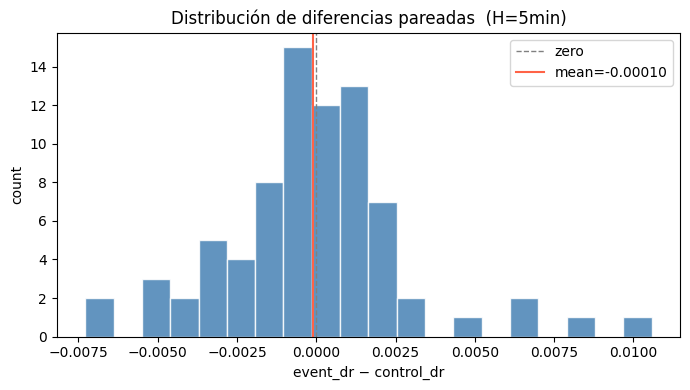

In [11]:
# ── Cell 10b: Distribución de diferencias pareadas ──────────────────────────
# pair_diff_i = event_dr_i − control_dr_i  (para H=5min)
import matplotlib.pyplot as plt

pair_diff = (
    returns_df["event_directed_ret"]
    - returns_df["control_directed_ret"]
)

print('pair_diff (event_dr − control_dr, H=5min)')
print(f'  mean   : {pair_diff.mean():+.6f}')
print(f'  median : {pair_diff.median():+.6f}')
print(f'  std    : {pair_diff.std():.6f}')
print(f'  P25    : {pair_diff.quantile(0.25):+.6f}')
print(f'  P75    : {pair_diff.quantile(0.75):+.6f}')
print(f'  min    : {pair_diff.min():+.6f}')
print(f'  max    : {pair_diff.max():+.6f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pair_diff, bins=20, edgecolor='white', color='steelblue', alpha=0.85)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='zero')
ax.axvline(pair_diff.mean(), color='tomato', linestyle='-', linewidth=1.5,
           label=f'mean={pair_diff.mean():+.5f}')
ax.set_xlabel('event_dr − control_dr')
ax.set_ylabel('count')
ax.set_title('Distribución de diferencias pareadas  (H=5min)')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ── Cell 11: Veredicto final — F1 + F2 ──────────────────────────────────────
print('=' * 62)
print('EXP10 VEREDICTO FINAL  (SPEC_HASH=7a809aaca7f3)')
print('=' * 62)
print(f'  {"Horizonte":<10}  {"Δ_obs":>10}  {"p_perm":>7}  {"IC_95 [lo, hi]":>28}  outcome')
print(f'  {"─"*10}  {"─"*10}  {"─"*7}  {"─"*28}  {"─"*7}')

ci5_lo, ci5_hi = result_5m["boot_ci_95"]
ci1_lo, ci1_hi = result_1m["boot_ci_95"]
print(f'  {"H=5 min":<10}  {result_5m["delta_obs"]:>+10.6f}  {result_5m["p_value_perm"]:>7.4f}  '
      f'[{ci5_lo:+.6f}, {ci5_hi:+.6f}]  {result_5m["outcome"]}')
print(f'  {"H=1 min":<10}  {result_1m["delta_obs"]:>+10.6f}  {result_1m["p_value_perm"]:>7.4f}  '
      f'[{ci1_lo:+.6f}, {ci1_hi:+.6f}]  {result_1m["outcome"]}')
print()

# F2 logic: effect at 1m that disappears at 5m → DÉBIL (F2)
f1_nulo  = result_5m["outcome"] == "NULO"
f2_active = (result_1m["outcome"] in ("FUERTE", "DÉBIL")) and f1_nulo

if f2_active:
    final = "DÉBIL  (F2 activo)"
    note  = "Efecto mecánico transitorio en H=1m; no hay reversión sostenida a H=5m."
elif f1_nulo:
    final = "NULO  (F1 activo)"
    note  = "No hay evidencia de reversión superior al control en ningún horizonte."
else:
    final = result_5m["outcome"]
    note  = ""

print(f'  Resultado final : {final}')
if note:
    print(f'  {note}')
print('=' * 62)

EXP10 VEREDICTO FINAL  (SPEC_HASH=7a809aaca7f3)
  Horizonte        Δ_obs   p_perm                IC_95 [lo, hi]  outcome
  ──────────  ──────────  ───────  ────────────────────────────  ───────
  H=5 min      -0.000095   0.6183  [-0.000735, +0.000584]  NULO
  H=1 min      -0.000130   0.7707  [-0.000483, +0.000205]  NULO

  Resultado final : NULO  (F1 activo)
  No hay evidencia de reversión superior al control en ningún horizonte.
